In [11]:
import pandas as pd

df = pd.read_csv('../output/slope_labels_011_015.csv')

df.head()

,folder,prefix,path,slope_avg
0,Depth_011,ZED2_KSC_020833,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,4.95
1,Depth_011,ZED2_KSC_020834,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,2.62
2,Depth_011,ZED2_KSC_020835,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,3.15
3,Depth_011,ZED2_KSC_020838,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,0.10
4,Depth_011,ZED2_KSC_020840,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,6.81


In [12]:
# 1. 'slope_avg' 컬럼을 숫자형(float)으로 변환합니다.
# errors='coerce'를 사용하면 숫자로 변환할 수 없는 이상한 문자(예: 'N/A')를 NaN으로 처리해줍니다.
df['slope_avg'] = pd.to_numeric(df['slope_avg'], errors='coerce')

In [13]:
df['slope_avg'] = abs(df['slope_avg'])
df.head()

,folder,prefix,path,slope_avg
0,Depth_011,ZED2_KSC_020833,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,4.95
1,Depth_011,ZED2_KSC_020834,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,2.62
2,Depth_011,ZED2_KSC_020835,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,3.15
3,Depth_011,ZED2_KSC_020838,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,0.10
4,Depth_011,ZED2_KSC_020840,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0208...,6.81


In [16]:
result = df[df['slope_avg'].abs() >= 20]
result

,folder,prefix,path,slope_avg
275,Depth_011,ZED2_KSC_021715,c:\wheel-safe\data\raw\Depth_011/ZED2_KSC_0217...,64.30
815,Depth_012,ZED2_KSC_022926,c:\wheel-safe\data\raw\Depth_012/ZED2_KSC_0229...,20.18
1187,Depth_012,ZED2_KSC_023390,c:\wheel-safe\data\raw\Depth_012/ZED2_KSC_0233...,21.58
1447,Depth_012,ZED2_KSC_023821,c:\wheel-safe\data\raw\Depth_012/ZED2_KSC_0238...,26.84
2335,Depth_014,ZED2_KSC_026071,c:\wheel-safe\data\raw\Depth_014/ZED2_KSC_0260...,61.07
2336,Depth_014,ZED2_KSC_026076,c:\wheel-safe\data\raw\Depth_014/ZED2_KSC_0260...,26.96


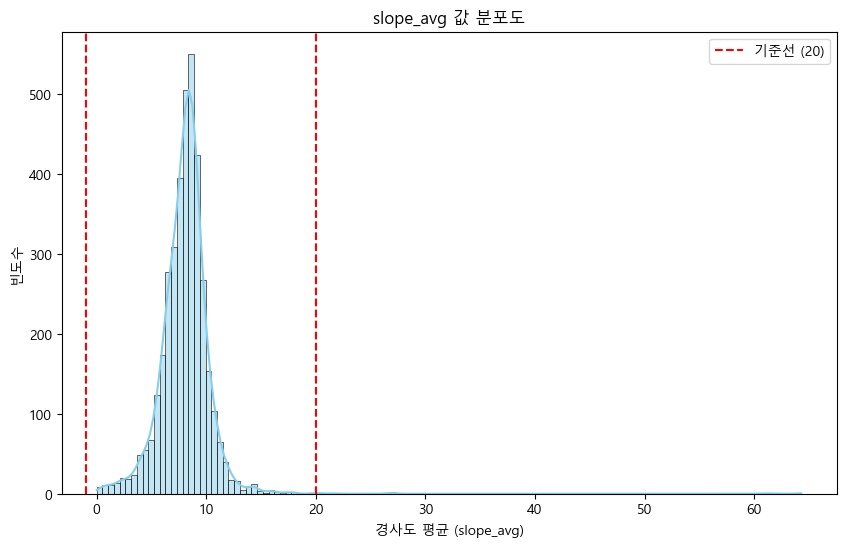

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope_avg 값 분포도')
plt.xlabel('경사도 평균 (slope_avg)')
plt.ylabel('빈도수')
plt.legend()
plt.show()

In [ ]:
# 50,51,52,53,54,56,75,201,202,203,204,205,208,210,211,212,214,216,218,219,220,221,222,223,224,226

In [ ]:
drop_idx = [
    48,
    49,
    50,
    51,
    52,
    54,
    73,
    199,
    200,
    201,
    202,
    203,
    206,
    208,
    209,
    210,
    212,
    214,
    216,
    217,
    218,
    219,
    220,
    221,
    222,
    224,
]

df = df.drop(index=drop_idx)
df = df.reset_index(drop=True)

In [4]:
df.to_csv('../output/23&24_output.csv', index=False)

In [ ]:
import os

import pandas as pd

# 1. 파일이 들어있는 폴더 경로 설정
# (실제 경로가 '/output/' 이라면 아래와 같이 작성합니다)
base_path = '../output/'

# 2. 합치고 싶은 파일 이름 리스트
target_files = [
    'slope_labels_002.csv',
    'slope_labels_003.csv',
    'slope_labels_004.csv',
    'slope_labels_006.csv',
]

all_data = []

for file in target_files:
    # 경로와 파일명을 합칩니다 (예: /output/slope_labels_002.csv)
    full_path = os.path.join(base_path, file)

    try:
        temp_df = pd.read_csv(full_path)
        all_data.append(temp_df)
        print(f'성공: {full_path} 읽기 완료')
    except FileNotFoundError:
        print(f'실패: {full_path} 파일을 찾을 수 없습니다. 경로를 확인해주세요.')

# 3. 통합 및 타입 변환
if all_data:
    df = pd.concat(all_data, ignore_index=True)
    df['slope_avg'] = pd.to_numeric(df['slope_avg'], errors='coerce')

    print('-' * 30)
    print(f'최종 합쳐진 데이터 행 개수: {len(df)}')
    print(df['slope_avg'].describe())
else:
    print('읽어온 데이터가 없습니다.')

성공: ../output/slope_labels_002.csv 읽기 완료
성공: ../output/slope_labels_003.csv 읽기 완료
성공: ../output/slope_labels_004.csv 읽기 완료
성공: ../output/slope_labels_006.csv 읽기 완료
------------------------------
최종 합쳐진 데이터 행 개수: 1996
count    1996.000000
mean        4.591859
std         4.189302
min         0.000000
25%         1.537500
50%         4.010000
75%         6.995000
max        61.330000
Name: slope_avg, dtype: float64


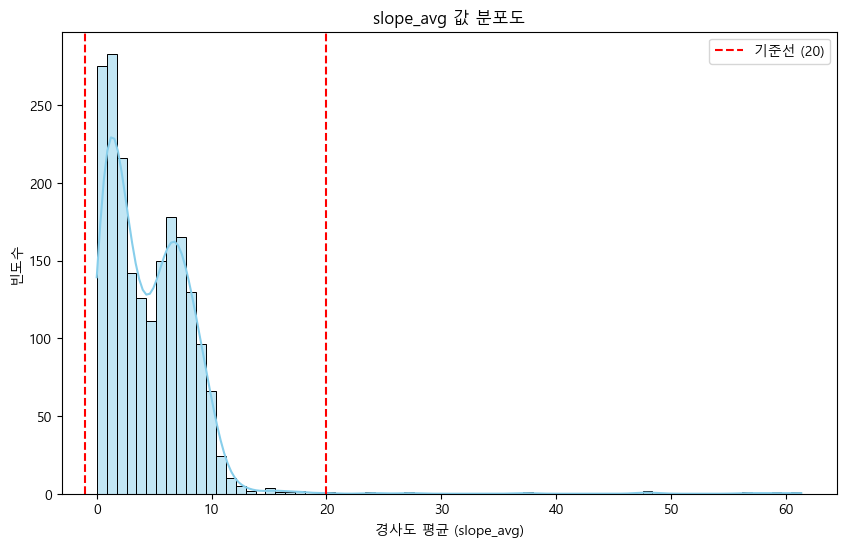

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df['slope_avg'].dropna(), kde=True, color='skyblue')

# 절댓값 20 지점에 가이드라인 표시
plt.axvline(20, color='red', linestyle='--', label='기준선 (20)')
plt.axvline(-1, color='red', linestyle='--')

plt.title('slope_avg 값 분포도')
plt.xlabel('경사도 평균 (slope_avg)')
plt.ylabel('빈도수')
plt.legend()
plt.show()